---
Author: The Tuan Trinh \
Date: 01/06/2026
---

In [25]:
import os
import platform
print("=" * 100)
print("OS Name:", os.name)
print("System:", platform.system())
print("Release:", platform.release())
print("Machine:", platform.machine())
print("Processor:", platform.processor())
print("Platform:", platform.platform())

print("\nEnvironment Variables (sample):")
for key, value in list(os.environ.items())[:15]:
    print(f"{key} = {value}")

OS Name: nt
System: Windows
Release: 10
Machine: AMD64
Processor: Intel64 Family 6 Model 142 Stepping 12, GenuineIntel
Platform: Windows-10-10.0.26200-SP0

Environment Variables (sample):
ALLUSERSPROFILE = C:\ProgramData
APPDATA = C:\Users\Admin\AppData\Roaming
APPLICATION_INSIGHTS_NO_STATSBEAT = true
CHROME_CRASHPAD_PIPE_NAME = \\.\pipe\crashpad_1956_PNLGHBSPHHYQZDLU
COMMONPROGRAMFILES = C:\Program Files\Common Files
COMMONPROGRAMFILES(X86) = C:\Program Files (x86)\Common Files
COMMONPROGRAMW6432 = C:\Program Files\Common Files
COMPUTERNAME = PMH
COMSPEC = C:\Windows\system32\cmd.exe
CONDA_DEFAULT_ENV = PMH
CONDA_EXE = C:\Users\Admin\miniconda3\Scripts\conda.exe
CONDA_PREFIX = C:\Users\Admin\miniconda3\envs\PMH
CONDA_PROMPT_MODIFIER = (PMH) 
CONDA_PYTHON_EXE = C:\Users\Admin\miniconda3\python.exe
CONDA_ROOT = C:\Users\Admin\miniconda3


In [26]:
platform.python_version()

'3.10.20'

# Lab 10 - Contours in OpenCV


## Contours : Getting Started



### What are contours?


In [27]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
h, w = 155, 256
img = np.full((h, w, 3), 255, dtype=np.uint8)
blue = np.array([7, 2, 97], dtype=np.uint8)
t = 4 
img[:t, :, :] = blue      
img[-t:, :, :] = blue     
img[:, :t, :] = blue      
img[:, -t:, :] = blue     

imgray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
ret, thresh = cv.threshold(imgray, 127, 255, 0)
contours, hierarchy = cv.findContours(thresh, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

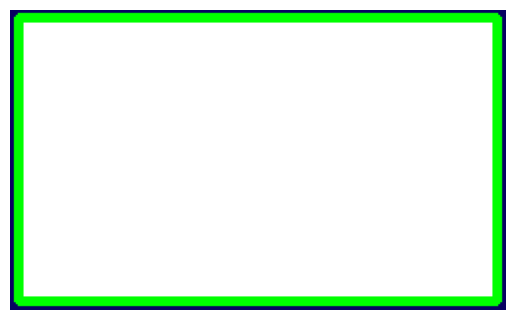

In [28]:
plt.imshow(cv.drawContours(img, contours, -1, (0,255,0), 3))
plt.axis("off")
plt.show()

## Contour Features

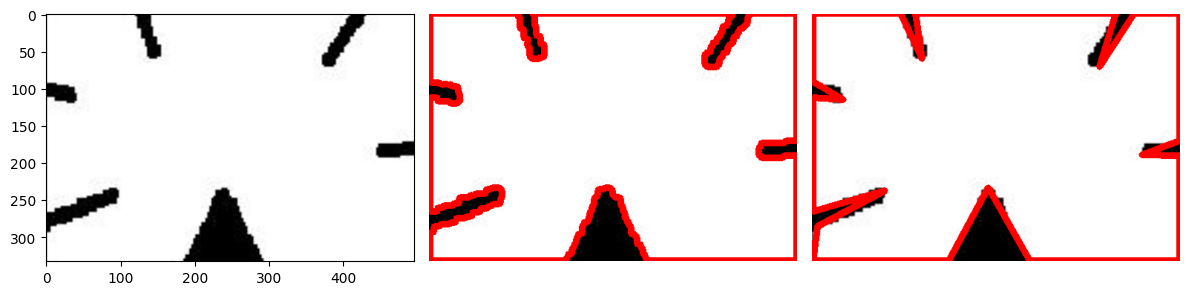

In [32]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('star.png', cv.IMREAD_GRAYSCALE)
_, thresh = cv.threshold(img, 127, 255, cv.THRESH_BINARY)
contours, hierarchy = cv.findContours(
    thresh,
    cv.RETR_EXTERNAL,
    cv.CHAIN_APPROX_SIMPLE
)
cnt = contours[0]
contour_img = cv.cvtColor(img, cv.COLOR_GRAY2BGR)
cv.drawContours(contour_img, [cnt], -1, (0, 0, 255), 8)
epsilon = 0.01 * cv.arcLength(cnt, True)
approx = cv.approxPolyDP(cnt, epsilon, True)
approx_img = cv.cvtColor(img, cv.COLOR_GRAY2BGR)
cv.drawContours(approx_img, [approx], -1, (0, 0, 255), 8)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.subplot(1,3,2)
plt.imshow(cv.cvtColor(contour_img, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(cv.cvtColor(approx_img, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.tight_layout()
plt.show()

## Contours : More Functions

### Convexity Defects

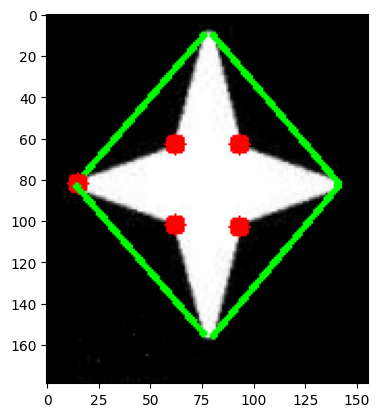

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('star_1.png')
assert img is not None, "file could not be read"
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
_, thresh = cv.threshold(gray, 127, 255, cv.THRESH_BINARY)
contours, hierarchy = cv.findContours(
    thresh,
    cv.RETR_TREE,
    cv.CHAIN_APPROX_SIMPLE
)
cnt = contours[0]
hull = cv.convexHull(cnt, returnPoints=False)
defects = cv.convexityDefects(cnt, hull)
result = img.copy()
for i in range(defects.shape[0]):
    s, e, f, d  = defects[i, 0]
    start       = tuple(cnt[s][0])
    end         = tuple(cnt[e][0])
    far         = tuple(cnt[f][0])
    cv.line(result, start, end, (0, 255, 0), 2)
    cv.circle(result, far, 5, (0, 0, 255), -1)
# plt.figure(figsize=(8,6))
plt.imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
plt.show()

### Match Shapes

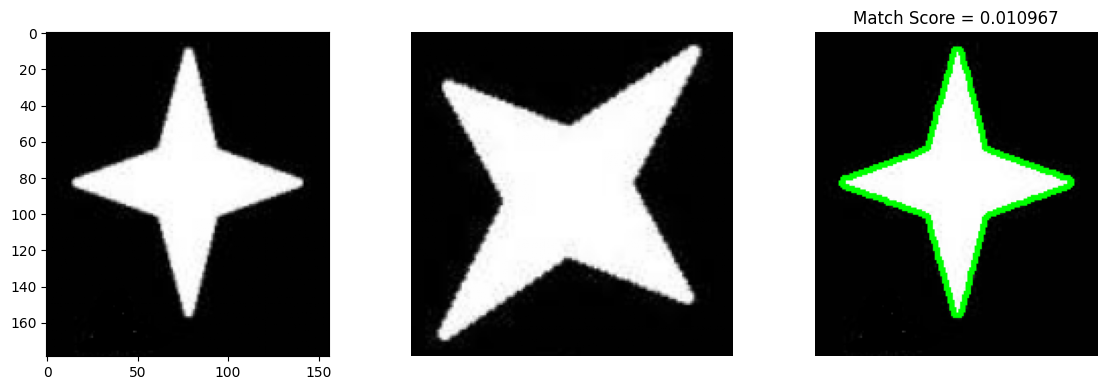

In [39]:
import cv2 as cv
import matplotlib.pyplot as plt

img1 = cv.imread('star_1.png', cv.IMREAD_GRAYSCALE)
img2 = cv.imread('star_2.png', cv.IMREAD_GRAYSCALE)

_, thresh1 = cv.threshold(img1, 127, 255, cv.THRESH_BINARY)
_, thresh2 = cv.threshold(img2, 127, 255, cv.THRESH_BINARY)
contours1, _ = cv.findContours(
    thresh1,
    cv.RETR_TREE,
    cv.CHAIN_APPROX_SIMPLE
)
contours2, _ = cv.findContours(
    thresh2,
    cv.RETR_TREE,
    cv.CHAIN_APPROX_SIMPLE
)
cnt1 = contours1[0]
cnt2 = contours2[0]
score = cv.matchShapes(
    cnt1,
    cnt2,
    cv.CONTOURS_MATCH_I1,
    0.0
)
draw1 = cv.cvtColor(img1, cv.COLOR_GRAY2BGR)
draw2 = cv.cvtColor(img2, cv.COLOR_GRAY2BGR)
cv.drawContours(draw1, [cnt1], -1, (0,255,0), 2)
cv.drawContours(draw2, [cnt2], -1, (0,255,0), 2)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img1, cmap='gray')
plt.subplot(1,3,2)
plt.imshow(img2, cmap='gray')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(cv.cvtColor(draw1, cv.COLOR_BGR2RGB))
plt.title(f'Match Score = {score:.6f}')
plt.axis('off')
plt.tight_layout()
plt.show()